In [1]:
# importing major libraries 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore'
)

In [2]:
df = pd.read_csv('Polynomial.csv').drop('Unnamed: 0',axis=1)

In [3]:
df

,X,Y
0,0.531918,2.340268
1,0.288274,2.583564
2,2.659518,9.311467
3,-1.360948,3.290790
4,-0.949151,3.710895
...,...,...
195,1.037013,2.979603
196,2.636448,11.709327
197,0.287318,3.688508
198,1.178571,4.144307


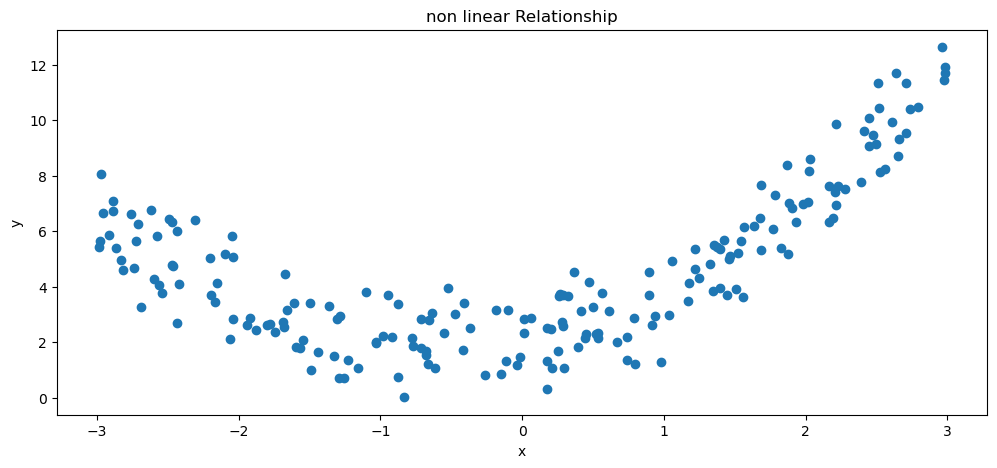

In [4]:
plt.figure(figsize=(12,5))
plt.scatter(df.X,df.Y)
plt.title('non linear Relationship')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [5]:
x = df.iloc[:,0:1]
y = df.Y

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
print('rows for training',x_train.shape[0])
print('rows for testing',x_test.shape[0])

rows for training 160
rows for testing 40


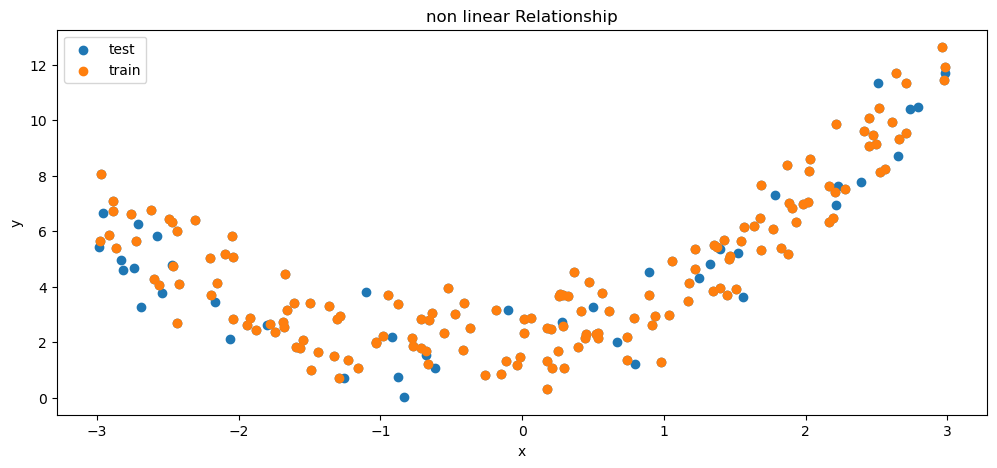

In [9]:
plt.figure(figsize=(12,5))
plt.scatter(df.X,df.Y,label='test')
plt.scatter(x_train,y_train,label='train')
plt.title('non linear Relationship')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [10]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr

LinearRegression()

In [11]:
lr.fit(x_train,y_train)

LinearRegression()

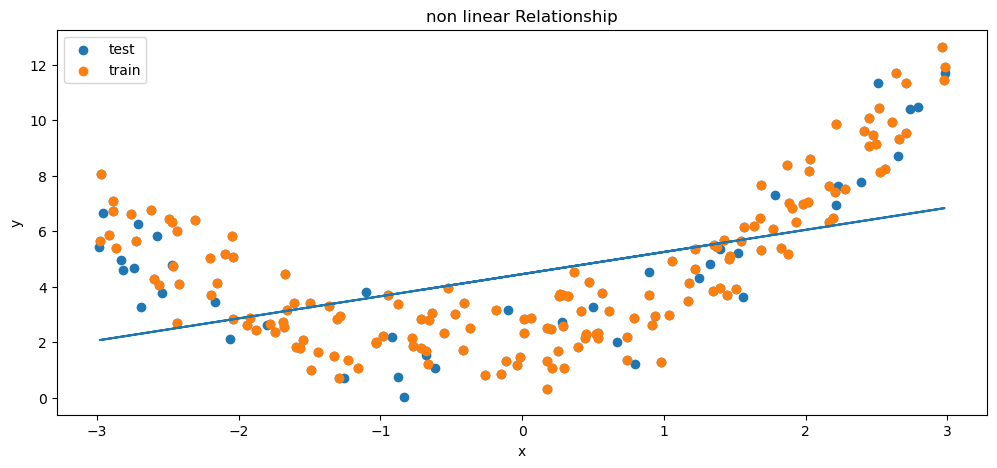

In [12]:
plt.figure(figsize=(12,5))
plt.scatter(df.X,df.Y,label='test')
plt.scatter(x_train,y_train,label='train')
plt.plot(x_train,lr.predict(x_train))
plt.title('non linear Relationship')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [13]:
y_pred = lr.predict(x_test )

from sklearn .metrics import mean_absolute_error,r2_score

print('r2',r2_score(y_test,y_pred))
print('error',mean_absolute_error(y_test,y_pred))

r2 0.2377217497370927
error 2.1778832964534844


In [14]:
# polynomial features
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=0)

In [15]:
# degree = 0 (constant)
# straight case of undefitting
# poly.fit(x_train)
# poly.transform(x_train)

In [16]:
poly = PolynomialFeatures(degree=2)

In [17]:
poly # quadratic

PolynomialFeatures()

In [18]:
poly.fit(x_train)

PolynomialFeatures()

In [19]:
# transformation
x_train_poly_2 = poly.transform(x_train)
x_test_poly_2 = poly.transform(x_test)

In [20]:
# print(x_train[0])

# 1.397611**0, 1.397611**1 , 1.397611**2

In [21]:
lr2 = LinearRegression()
lr2

LinearRegression()

In [22]:
lr2.fit(x_train_poly_2,y_train)

LinearRegression()

In [23]:
y_pred2 = lr2.predict(x_test_poly_2)

In [24]:
print('r2 of degree 1',r2_score(y_test,y_pred))
print('r2 of degree 2',r2_score(y_test,y_pred2))

r2 of degree 1 0.2377217497370927
r2 of degree 2 0.8422806489893417


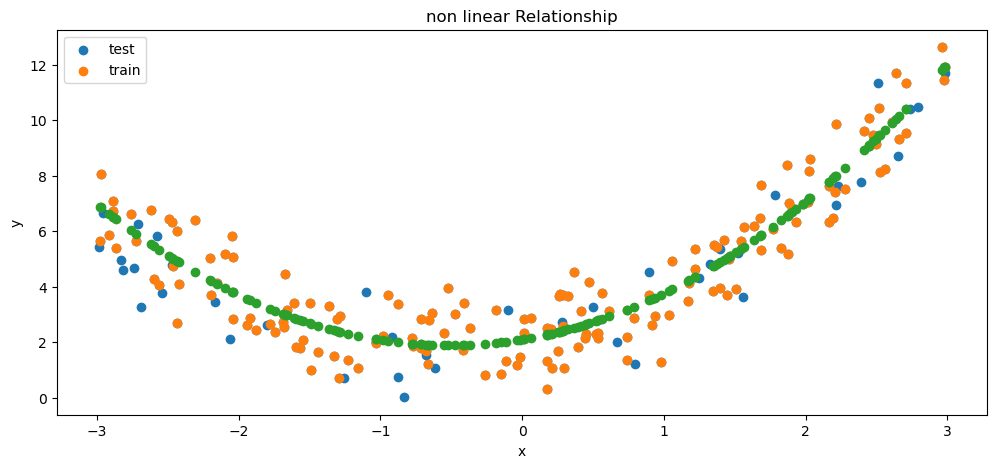

In [25]:
plt.figure(figsize=(12,5))
plt.scatter(df.X,df.Y,label='test')
plt.scatter(x_train,y_train,label='train')
plt.scatter(x_train,lr2.predict(x_train_poly_2))
plt.title('non linear Relationship')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [26]:
# example of overfitting 
# degree 40
poly = PolynomialFeatures(degree=40)
poly.fit(x_train)
# transformation
x_train_poly_20 = poly.transform(x_train)
x_test_poly_20 = poly.transform(x_test)
# algorithm 
lr20 = LinearRegression()
lr20
lr20.fit(x_train_poly_20,y_train)
y_pred20 = lr20.predict(x_test_poly_20)

In [27]:
print('r2 of degree 1',r2_score(y_test,y_pred))
print('r2 of degree 2',r2_score(y_test,y_pred2))
print('r2 of degree 20',r2_score(y_test,y_pred20))

r2 of degree 1 0.2377217497370927
r2 of degree 2 0.8422806489893417
r2 of degree 20 -0.8165694802060368


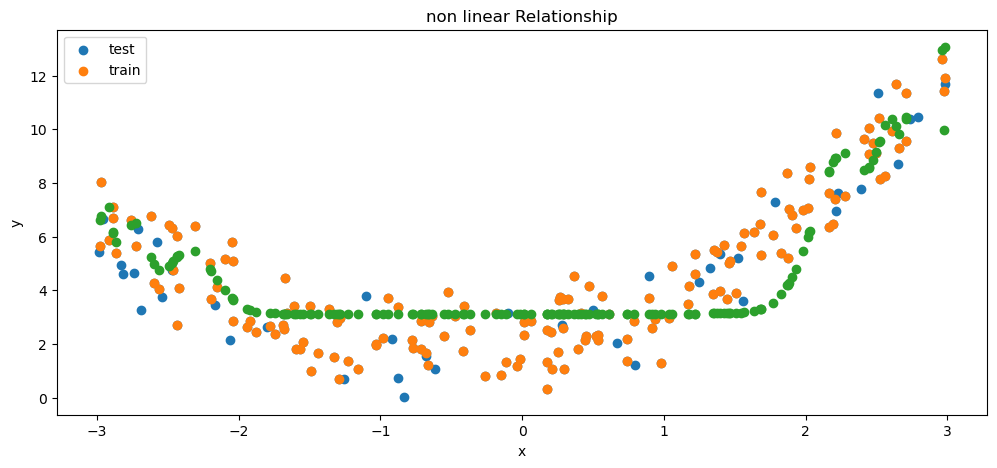

In [28]:
plt.figure(figsize=(12,5))
plt.scatter(df.X,df.Y,label='test')
plt.scatter(x_train,y_train,label='train')
plt.scatter(x_train,lr20.predict(x_train_poly_20))
plt.title('non linear Relationship')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()